# CSE425 music-context project: data audit

This notebook reads the real MusicCaps, GTZAN, and MagnaTagATune files used by the experiments. It does not generate synthetic examples.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
assert (ROOT / 'config.yaml').exists(), 'Run this notebook from the project root or notebooks folder.'
ROOT

WindowsPath('E:/coding/CSE425')

## Frozen split sizes and leakage audit

In [2]:
audit = json.loads((ROOT / 'results/data_split_audit.json').read_text(encoding='utf-8'))
rows = []
for dataset, details in audit.items():
    counts = details.get('split_counts', details.get('counts', {}))
    rows.append({'dataset': dataset, **counts})
pd.DataFrame(rows).fillna('-')

,dataset,train,val,test
0,musiccaps,2396,267,2858
1,mtat,18709,1825,5329
2,gtzan,797,99,103


## GTZAN class distribution

,train,val,test
blues,80,10,10
classical,80,10,10
country,80,10,10
disco,80,10,10
hiphop,80,10,10
jazz,79,10,10
metal,79,9,12
pop,79,10,11
reggae,80,10,10
rock,80,10,10


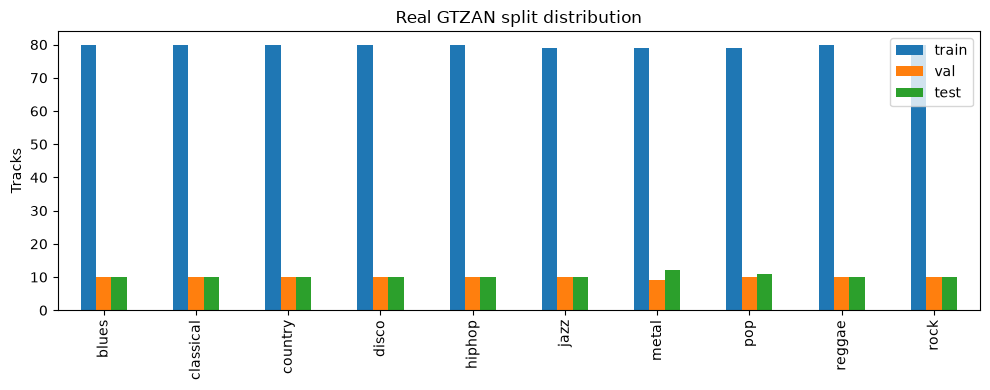

In [3]:
gtzan = json.loads((ROOT / 'data/splits/gtzan_splits.json').read_text(encoding='utf-8'))
genre_counts = {split: pd.Series([track.split('.')[0] for track in gtzan[split]]).value_counts().sort_index() for split in ('train', 'val', 'test')}
genre_frame = pd.DataFrame(genre_counts).fillna(0).astype(int)
display(genre_frame)
genre_frame.plot(kind='bar', figsize=(10, 4), title='Real GTZAN split distribution')
plt.ylabel('Tracks')
plt.tight_layout()

## MTAT training-only target prevalence

The target prevalence below is calculated only from official training shards 0--b.

,training prevalence
classical,0.176493
slow,0.133198
techno,0.112459
electronic,0.098188
fast,0.086376
rock,0.083970
ambient,0.071623
indian,0.057245
opera,0.046662
quiet,0.040248


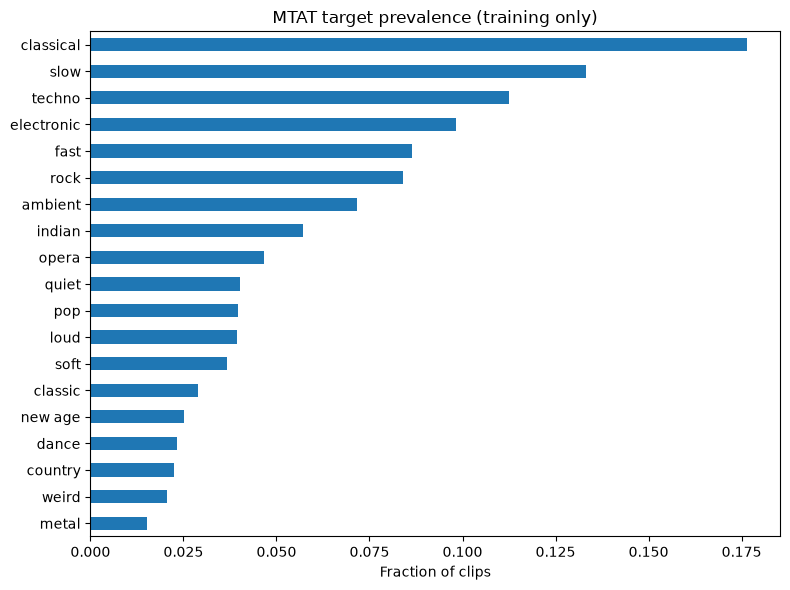

In [4]:
from src.dataset import TARGET_TAGS
mtat_split = json.loads((ROOT / 'data/splits/mtat_splits.json').read_text(encoding='utf-8'))
annotations = pd.read_csv(ROOT / 'data/raw/magnatagatune/annotations_final.csv', sep='\t').set_index('clip_id')
train_rows = annotations.loc[mtat_split['train']]
prevalence = train_rows[TARGET_TAGS].mean().sort_values(ascending=False)
display(prevalence.rename('training prevalence').to_frame())
prevalence.sort_values().plot(kind='barh', figsize=(8, 6), title='MTAT target prevalence (training only)')
plt.xlabel('Fraction of clips')
plt.tight_layout()

## Completed experimental results

Only JSON files produced by completed training runs are displayed.

In [5]:
for filename in ('task1_results.json', 'task2_results.json', 'task3_results.json', 'task4_results.json'):
    path = ROOT / 'results' / filename
    if path.exists():
        print(f'\n{filename}')
        result = json.loads(path.read_text(encoding='utf-8'))
        if filename == 'task1_results.json':
            display(pd.DataFrame([result['test_metrics']]).drop(columns=['per_tag']))
        elif filename == 'task2_results.json':
            display(pd.DataFrame({name: block['test_metrics'] for name, block in result.items() if name in ('gnn', 'cnn')}).T[['accuracy', 'macro_f1']])
        elif filename == 'task3_results.json':
            display(pd.DataFrame({name: block['test_metrics'] for name, block in result['results'].items()}).T[['macro_f1', 'micro_f1', 'mean_auc_pr']])
        else:
            display(pd.DataFrame({direction: result[direction] for direction in ('caption_to_audio', 'audio_to_caption')}).T)


task1_results.json


,macro_f1,micro_f1,macro_precision,macro_recall,micro_precision,micro_recall,mean_auc_pr,threshold,num_samples,num_tags
0,0.286332,0.39998,0.255557,0.460484,0.291983,0.634759,0.2979,0.7,2858,191



task2_results.json


,accuracy,macro_f1
gnn,0.349515,0.336355
cnn,0.786408,0.785898



task3_results.json


,macro_f1,micro_f1,mean_auc_pr
bert_only,0.28123,0.348475,0.252482
gnn_only,0.296661,0.352556,0.24423
concat,0.370763,0.437871,0.354141
cross_attention,0.378616,0.444444,0.354528



task4_results.json


,R@1,R@5,R@10
caption_to_audio,0.021505,0.096774,0.172043
audio_to_caption,0.043011,0.139785,0.215054
